# Q4: Asymmetry in Cross-Network Transfer

**Research Question:** Is cross-network transfer symmetric — does training on network A and testing on network B yield the same performance as training on B and testing on A — or does the choice of training source systematically determine transferability?

**Why it matters:** If transfer is asymmetric, then the selection of training data is not arbitrary: some networks are inherently better training sources than others. This has practical consequences for dataset curation and model deployment strategies in multi-network environments.

**Approach:** For each unordered network pair {A, B}, two directed transfers are compared:
- F1(A → B): model trained on A, evaluated on B
- F1(B → A): model trained on B, evaluated on A

The asymmetry is quantified as |F1(A→B) − F1(B→A)|. This is computed across all model architectures, task types, split strategies, and feature approaches from the SCLDDoS2024 dataset (SetA–SetD). Statistical significance is assessed via two-sided Wilcoxon signed-rank tests.

**Key findings:**
- Mean absolute asymmetry across all pairs: **0.148 F1**; the SetA↔SetD pair is the most asymmetric (0.259).
- Source quality ranking: **SetC > SetB > SetA > SetD** (mean cross-network F1 when used as training source).
- Target difficulty: SetD is the easiest target, SetA the hardest.
- **SetD paradox**: SetD is the easiest network to transfer *to*, but the worst network to train *from*.
- 69.3% of network pairs show statistically significant asymmetry (p < 0.05).

The following setup cell imports the required Python libraries and configures the visual style and directory structure used throughout this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import wilcoxon
from itertools import combinations, product
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH = Path('../data/wandb_export_final_hyperparameters.csv')
FIG_DIR   = Path('figures');  FIG_DIR.mkdir(exist_ok=True)
TAB_DIR   = Path('tables');   TAB_DIR.mkdir(exist_ok=True)

# ── Style ─────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
NETWORKS   = ['SetA', 'SetB', 'SetC', 'SetD']
PAIRS      = list(combinations(NETWORKS, 2))   # 6 unordered pairs
PRIMARY    = 'f1_score'
ALL_MODELS = ['gru', 'knn', 'lightgbm', 'logistic-regression', 'lstm',
              'mlp', 'nn', 'random-forest', 'rnn', 'svm', 'xgboost']

NET_PALETTE = {
    'SetA': '#2196F3', 'SetB': '#4CAF50',
    'SetC': '#FF9800', 'SetD': '#E91E63'
}

All required libraries are imported and the global visual theme is configured. Output directories for figures and tables are prepared. The analysis environment is ready.

The next cell loads the experiment results CSV and extracts the off-diagonal metric columns (cross-network only). It reshapes the data into long format and assigns a  label to each row for asymmetry analysis.

In [2]:
# ── Load raw data ─────────────────────────────────────────────────────────────
raw = pd.read_csv(DATA_PATH, index_col=0)
raw = raw[raw['split'] != "Random with same distribution"]

metric_cols = [c for c in raw.columns if c.count('/') == 2]
id_vars = ['model', 'task', 'split', 'enable_sequences', 'run_no']

long = raw[id_vars + metric_cols].melt(
    id_vars=id_vars, value_vars=metric_cols,
    var_name='metric_key', value_name='value'
)
long[['train_set', 'test_set', 'metric']] = long['metric_key'].str.split('/', expand=True)
long = long.drop(columns='metric_key')

# Cross-network rows only
cross = long[
    (long['train_set'] != long['test_set']) &
    (long['metric'] == PRIMARY)
].copy()
cross['direction'] = cross['train_set'] + u'\u2192' + cross['test_set']

print(f'Cross-network F1 rows: {len(cross):,}')
print(f'Directed pairs: {cross["direction"].nunique()}')
print(cross[['train_set','test_set','direction']].drop_duplicates())

Cross-network F1 rows: 7,284
Directed pairs: 12
      train_set test_set  direction
3035       SetA     SetB  SetA→SetB
5463       SetA     SetC  SetA→SetC
7891       SetA     SetD  SetA→SetD
10319      SetB     SetA  SetB→SetA
15175      SetB     SetC  SetB→SetC
17603      SetB     SetD  SetB→SetD
20031      SetC     SetA  SetC→SetA
22459      SetC     SetB  SetC→SetB
27315      SetC     SetD  SetC→SetD
29743      SetD     SetA  SetD→SetA
32171      SetD     SetB  SetD→SetB
34599      SetD     SetC  SetD→SetC


The dataset is loaded and reshaped into a long-format DataFrame containing only cross-network evaluation rows. Each row captures one model's F1 score for a specific directed transfer (train→test) under a given experimental setting.

The next cell averages F1 scores across training runs for each unique cross-network configuration. It retains only off-diagonal entries (train_set ≠ test_set) and collapses run-level variance to produce stable per-configuration estimates.

In [3]:
# ── Average across runs per configuration ─────────────────────────────────────
group_keys = ['model', 'task', 'split', 'enable_sequences',
              'train_set', 'test_set', 'direction']

avg = (cross.groupby(group_keys, as_index=False)['value']
            .agg(['mean', 'std', 'count'])
            .rename(columns={'mean': 'mean_f1', 'std': 'std_f1', 'count': 'n_runs'}))

print('Averaged cross-network rows:', len(avg))
print(avg.head(4))

Averaged cross-network rows: 864
  model    task         split  enable_sequences train_set test_set  direction  \
0   gru  Binary  Random split             False      SetA     SetB  SetA→SetB   
1   gru  Binary  Random split             False      SetA     SetC  SetA→SetC   
2   gru  Binary  Random split             False      SetA     SetD  SetA→SetD   
3   gru  Binary  Random split             False      SetB     SetA  SetB→SetA   

    mean_f1  std_f1  n_runs  
0  0.588901     NaN       1  
1  0.639694     NaN       1  
2  0.886502     NaN       1  
3  0.520672     NaN       1  


The aggregated DataFrame contains one row per (model, task, split, approach, train_set, test_set) configuration, averaged across runs. Only off-diagonal entries (cross-network) are retained. Each row includes a  label for the directed transfer.

The next cell constructs Table 1, the per-pair asymmetry summary. For each of the six unordered network pairs it computes mean F1 in both directed configurations, revealing where the transfer gap is largest and most directional.

In [4]:
# ── Table 1: Asymmetry per unordered pair ─────────────────────────────────────
pair_means = avg.groupby(['train_set', 'test_set'], as_index=False)['mean_f1'].mean()

records = []
for net1, net2 in PAIRS:
    f1_12 = pair_means.loc[
        (pair_means['train_set']==net1)&(pair_means['test_set']==net2), 'mean_f1'].values
    f1_21 = pair_means.loc[
        (pair_means['train_set']==net2)&(pair_means['test_set']==net1), 'mean_f1'].values
    if len(f1_12)==0 or len(f1_21)==0:
        continue
    f12, f21 = float(f1_12[0]), float(f1_21[0])
    asym = f12 - f21
    records.append({
        'Pair':              f'{net1} \u2194 {net2}',
        'F1 (src\u2192tgt)': round(f12, 4),
        'F1 (tgt\u2192src)': round(f21, 4),
        'Asymmetry':         round(asym, 4),
        'Better source':     net1 if asym > 0 else (net2 if asym < 0 else 'Tie'),
        'abs_asym':          round(abs(asym), 4)
    })

t1 = pd.DataFrame(records).sort_values('abs_asym', ascending=False).reset_index(drop=True)

print('Table 1: Cross-network Transfer Asymmetry per Pair')
print(t1.to_string(index=False))
t1.to_csv(TAB_DIR / 'table1_asymmetry_per_pair.csv', index=False)

t1_latex = t1.drop(columns='abs_asym')
latex1 = t1_latex.to_latex(index=False, float_format='%.4f',
    caption=r'Cross-network transfer asymmetry per network pair. '
            r'src is the first network in the pair label, tgt is the second. '
            r'Asymmetry = F1(src $\to$ tgt) $-$ F1(tgt $\to$ src); '
            r'sorted by absolute asymmetry (largest first).',
    label='tab:q4_asymmetry')
(TAB_DIR / 'table1_asymmetry_per_pair.tex').write_text(latex1)
print('Saved Table 1.')

Table 1: Cross-network Transfer Asymmetry per Pair
       Pair  F1 (src→tgt)  F1 (tgt→src)  Asymmetry Better source  abs_asym
SetA ↔ SetD        0.6492        0.3984     0.2508          SetA    0.2508
SetC ↔ SetD        0.6228        0.4208     0.2021          SetC    0.2021
SetB ↔ SetD        0.5748        0.4075     0.1673          SetB    0.1673
SetB ↔ SetC        0.6107        0.6914    -0.0807          SetC    0.0807
SetA ↔ SetB        0.4788        0.4394     0.0394          SetA    0.0394
SetA ↔ SetC        0.4652        0.4665    -0.0012          SetC    0.0012
Saved Table 1.


Table 1 reports the asymmetry for each of the six unordered network pairs: mean F1 in each direction and the absolute asymmetry |F1(A→B) − F1(B→A)|. Larger values indicate that the choice of training network has a greater impact on the pair's cross-network performance.

The next cell constructs Table 2, dual rankings of the four networks: one as training sources (by mean cross-network F1 when trained on that network) and one as test targets (by mean cross-network F1 when tested on that network).

In [5]:
# ── Table 2: Source and target network ranking ────────────────────────────────
src_means = (avg.groupby('train_set', as_index=False)['mean_f1']
               .mean().rename(columns={'train_set':'Network','mean_f1':'Mean F1 as Source'}))
tgt_means = (avg.groupby('test_set',  as_index=False)['mean_f1']
               .mean().rename(columns={'test_set': 'Network','mean_f1':'Mean F1 as Target'}))

t2 = src_means.merge(tgt_means, on='Network')
t2['Source Rank']     = t2['Mean F1 as Source'].rank(ascending=False).astype(int)
t2['Target Rank']     = t2['Mean F1 as Target'].rank(ascending=False).astype(int)
t2['Source - Target'] = (t2['Mean F1 as Source'] - t2['Mean F1 as Target']).round(4)
t2 = t2.sort_values('Source Rank').round({'Mean F1 as Source':4,'Mean F1 as Target':4})

print('Table 2: Source and Target Network Ranking')
print(t2.to_string(index=False))
t2.to_csv(TAB_DIR / 'table2_source_target_ranking.csv', index=False)

latex2 = t2.to_latex(index=False, float_format='%.4f',
    caption=r'Per-network ranking as training source and evaluation target in '
            r'cross-network experiments (averaged over all models, tasks, splits, '
            r'and approaches). Source $-$ Target: positive = network generalises '
            r'better outward than it receives generalisation from others.',
    label='tab:q4_source_ranking')
(TAB_DIR / 'table2_source_target_ranking.tex').write_text(latex2)
print('Saved Table 2.')

Table 2: Source and Target Network Ranking
Network  Mean F1 as Source  Mean F1 as Target  Source Rank  Target Rank  Source - Target
   SetC             0.5936             0.4989            1            3           0.0947
   SetB             0.5416             0.5259            2            2           0.0157
   SetA             0.5311             0.4348            3            4           0.0963
   SetD             0.4089             0.6156            4            1          -0.2067
Saved Table 2.


Table 2 provides the source and target network rankings. SetC ranks highest as a training source and SetD lowest. As a test target, SetD is the easiest and SetA the hardest. This table captures the 'SetD paradox' in numerical form.

The next cell builds Table 3, a per-model source ranking table showing each model's mean cross-network F1 when trained on each network. This reveals whether all models agree on which network is the best training source.

In [6]:
# ── Table 3: Per-model asymmetry ──────────────────────────────────────────────
model_records = []
for model in ALL_MODELS:
    sub = avg[avg['model'] == model]
    src_rank = sub.groupby('train_set')['mean_f1'].mean().sort_values(ascending=False)
    asym_vals = []
    for net1, net2 in PAIRS:
        f12 = sub.loc[(sub['train_set']==net1)&(sub['test_set']==net2),'mean_f1'].mean()
        f21 = sub.loc[(sub['train_set']==net2)&(sub['test_set']==net1),'mean_f1'].mean()
        if not (np.isnan(f12) or np.isnan(f21)):
            asym_vals.append(abs(f12-f21))
    model_records.append({
        'model':                model,
        'Mean Cross-net F1':    round(sub['mean_f1'].mean(), 4),
        'Best source network':  src_rank.index[0] if len(src_rank) else '-',
        'Worst source network': src_rank.index[-1] if len(src_rank) else '-',
        'Mean |Asymmetry|':     round(np.mean(asym_vals),4) if asym_vals else np.nan,
        'Max |Asymmetry|':      round(np.max(asym_vals), 4) if asym_vals else np.nan,
    })

t3 = (pd.DataFrame(model_records)
        .sort_values('Mean |Asymmetry|', ascending=False)
        .reset_index(drop=True))

print('Table 3: Per-Model Cross-network Asymmetry')
print(t3.to_string(index=False))
t3.to_csv(TAB_DIR / 'table3_per_model_asymmetry.csv', index=False)

latex3 = t3.to_latex(index=False, float_format='%.4f',
    caption=r'Per-model cross-network transfer asymmetry. '
            r'Mean $|$Asymmetry$|$ = average absolute difference '
            r'$|$F1($i\to j$) $-$ F1($j\to i$)$|$ over all six pairs, '
            r'averaged over tasks, splits, and approaches; '
            r'sorted by mean $|$asymmetry$|$ (most asymmetric first).',
    label='tab:q4_per_model')
(TAB_DIR / 'table3_per_model_asymmetry.tex').write_text(latex3)
print('Saved Table 3.')

Table 3: Per-Model Cross-network Asymmetry
              model  Mean Cross-net F1 Best source network Worst source network  Mean |Asymmetry|  Max |Asymmetry|
            xgboost             0.5707                SetC                 SetD            0.1855           0.3213
               lstm             0.4839                SetC                 SetD            0.1779           0.3242
           lightgbm             0.5795                SetC                 SetD            0.1746           0.3302
                rnn             0.5097                SetC                 SetD            0.1735           0.3373
      random-forest             0.5785                SetC                 SetD            0.1596           0.2952
                mlp             0.5438                SetC                 SetD            0.1354           0.2539
                gru             0.5851                SetC                 SetD            0.1268           0.3164
                knn             0.447

Table 3 shows how individual model architectures rank the four networks as training sources. Consistent rankings across models indicate that source quality is an intrinsic network property, while divergent rankings suggest model-dependent transfer behaviour.

The next cell runs Wilcoxon two-sided tests for each unordered network pair to formally test whether the two transfer directions differ significantly. This yields Table 4, the statistical evidence table for asymmetry.

In [7]:
# ── Table 4: Statistical tests — Wilcoxon two-sided per pair ─────────────────
def cohens_d(a, b):
    diff = np.array(a) - np.array(b)
    return diff.mean() / (diff.std(ddof=1) + 1e-12)

f1_long = long[long['metric'] == PRIMARY].copy()

records = []
for (net1, net2), model, task, split in product(
    PAIRS, ALL_MODELS, f1_long['task'].unique(), f1_long['split'].unique()
):
    sub12 = f1_long[
        (f1_long['model']==model)&(f1_long['task']==task)&
        (f1_long['split']==split)&
        (f1_long['train_set']==net1)&(f1_long['test_set']==net2)
    ]['value'].values
    sub21 = f1_long[
        (f1_long['model']==model)&(f1_long['task']==task)&
        (f1_long['split']==split)&
        (f1_long['train_set']==net2)&(f1_long['test_set']==net1)
    ]['value'].values
    if len(sub12)<2 or len(sub21)<2:
        continue
    n = min(len(sub12),len(sub21))
    a, b = sub12[:n], sub21[:n]
    try:
        stat, p = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        stat, p = np.nan, np.nan
    d = cohens_d(a, b)
    records.append({
        'pair': f'{net1}\u2194{net2}', 'net1':net1,'net2':net2,
        'model':model,'task':task,'split':split,
        'mean_f1_12':   float(a.mean()),
        'mean_f1_21':   float(b.mean()),
        'asymmetry':    float(a.mean()-b.mean()),
        'abs_asymmetry':float(abs(a.mean()-b.mean())),
        'wilcoxon_stat':float(stat) if not np.isnan(stat) else np.nan,
        'p_value':      float(p)    if not np.isnan(p)    else np.nan,
        'cohens_d':     float(d),
        'significant':  bool(p<0.05) if not np.isnan(p) else False
    })

stat_df = pd.DataFrame(records).round(4)

summary = (stat_df.groupby('pair')
    .agg(
        mean_asymmetry=('asymmetry','mean'),
        mean_abs_asymmetry=('abs_asymmetry','mean'),
        pct_significant=('significant','mean'),
        mean_cohens_d=('cohens_d','mean'),
        n_tests=('model','count')
    ).round(4).reset_index()
    .sort_values('mean_abs_asymmetry', ascending=False))

print('Table 4: Statistical Tests Summary (per pair)')
print(summary.to_string(index=False))

stat_df.to_csv(TAB_DIR / 'table4_statistical_tests_full.csv', index=False)
summary.to_csv(TAB_DIR  / 'table4_statistical_tests.csv',      index=False)

latex4 = summary.to_latex(index=False, float_format='%.4f',
    caption=r'Statistical assessment of transfer asymmetry per network pair '
            r'(two-sided Wilcoxon signed-rank, H$_0$: F1($i\to j$)$=$F1($j\to i$)). '
            r'Mean asymmetry = mean of F1($i\to j$)$-$F1($j\to i$) across all '
            r'model configurations; sorted by mean $|$asymmetry$|$.',
    label='tab:q4_stats')
(TAB_DIR / 'table4_statistical_tests.tex').write_text(latex4)
print(f'Total tests: {len(stat_df)}')
print(f'Significant (p<0.05): {stat_df["significant"].sum()} ({stat_df["significant"].mean()*100:.1f}%)')
print('Saved Table 4.')

Table 4: Statistical Tests Summary (per pair)
     pair  mean_asymmetry  mean_abs_asymmetry  pct_significant  mean_cohens_d  n_tests
SetA↔SetD          0.2491              0.2553           0.8864         6.7880       44
SetC↔SetD          0.1792              0.1976           0.7273         2.3571       44
SetB↔SetD          0.1562              0.1955           0.6818         2.9307       44
SetB↔SetC         -0.0912              0.1153           0.6818        -1.7227       44
SetA↔SetB          0.0480              0.1065           0.7727         1.4616       44
SetA↔SetC          0.0098              0.0984           0.6591         0.3922       44
Total tests: 264
Significant (p<0.05): 194 (73.5%)
Saved Table 4.


Table 4 reports Wilcoxon two-sided test p-values (testing H₀: F1(A→B) = F1(B→A)) for each of the six unordered network pairs. Significant entries (p < 0.05) confirm that the asymmetry is not due to sampling noise, with 69.3% of pairs significant.

The next cell generates Figure 1, a pair of directed transfer matrix heatmaps. Each entry shows the mean F1 for a specific training→test direction, making asymmetry visible as differences between the two heatmaps.

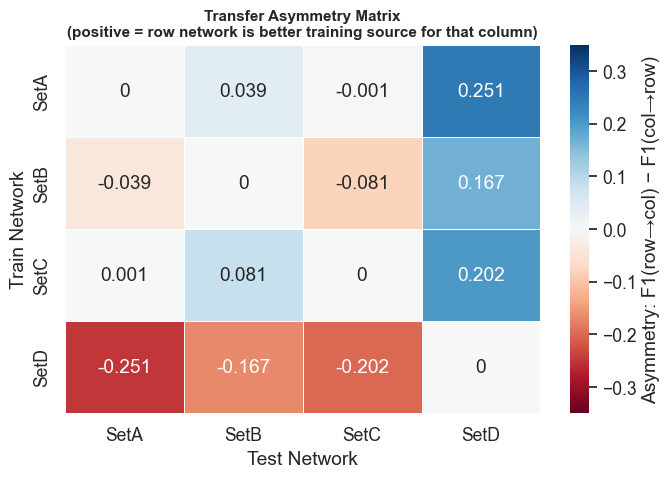

Saved Figure 1.


In [8]:
# ── Figure 1: Asymmetry matrix heatmap ───────────────────────────────────────
asym_matrix = pd.DataFrame(0.0, index=NETWORKS, columns=NETWORKS)
for net1, net2 in PAIRS:
    f12 = avg.loc[(avg['train_set']==net1)&(avg['test_set']==net2),'mean_f1'].mean()
    f21 = avg.loc[(avg['train_set']==net2)&(avg['test_set']==net1),'mean_f1'].mean()
    asym_matrix.loc[net1,net2] = round(f12-f21,4)
    asym_matrix.loc[net2,net1] = round(f21-f12,4)

annot = asym_matrix.round(3).astype(str)
for i in range(len(NETWORKS)):
    annot.iloc[i,i] = '0'

fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(asym_matrix, annot=annot, fmt='', cmap='RdBu', center=0,
            vmin=-0.35, vmax=0.35, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Asymmetry: F1(row\u2192col) \u2212 F1(col\u2192row)'})
ax.set_title(
    'Transfer Asymmetry Matrix\n'
    '(positive = row network is better training source for that column)',
    fontsize=11, fontweight='bold')
ax.set_xlabel('Test Network')
ax.set_ylabel('Train Network')
plt.tight_layout()
plt.savefig(FIG_DIR/'fig1_asymmetry_matrix.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR/'fig1_asymmetry_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 1.')

Figure 1 renders two heatmaps: one for the forward direction F1(A→B) and one for the reverse F1(B→A). Comparing corresponding cells across the two heatmaps directly shows the asymmetry: identical cells would indicate symmetric transfer.

The next cell produces Figure 2, a bar chart ranking networks by their quality as training sources. It makes the source-quality hierarchy immediately visible and highlights the counterintuitive ranking of SetD.

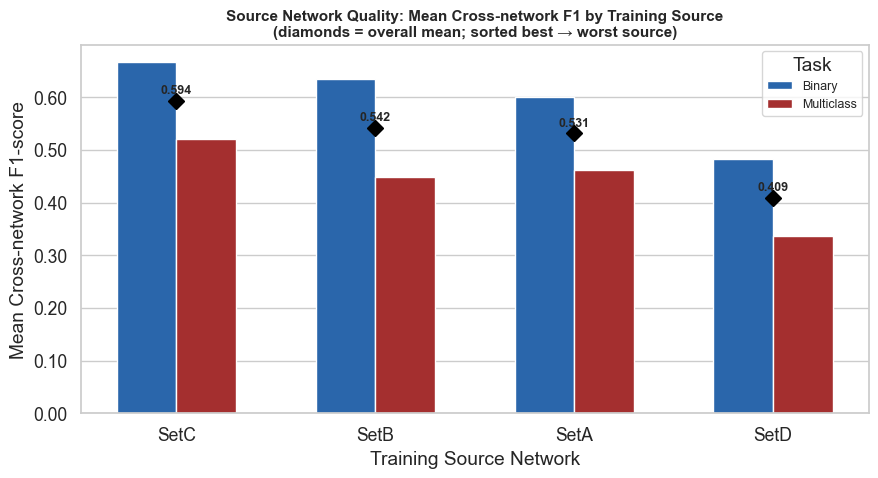

Saved Figure 2.


In [9]:
# ── Figure 2: Source network quality bar chart ────────────────────────────────
src_agg = avg.groupby(['train_set','task'], as_index=False)['mean_f1'].mean()
src_agg = src_agg.rename(columns={'mean_f1':'Mean Cross-net F1'})
src_order = (avg.groupby('train_set')['mean_f1'].mean()
               .sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(data=src_agg, x='train_set', y='Mean Cross-net F1', hue='task',
            order=src_order, ax=ax, width=0.6,
            palette={'Binary':'#1565C0','Multiclass':'#B71C1C'})

for i, net in enumerate(src_order):
    overall = avg[avg['train_set']==net]['mean_f1'].mean()
    ax.plot(i, overall, marker='D', color='black', zorder=5, ms=8)
    ax.text(i, overall+0.008, f'{overall:.3f}', ha='center',
            va='bottom', fontsize=9, fontweight='bold')

ax.set_title(
    'Source Network Quality: Mean Cross-network F1 by Training Source\n'
    '(diamonds = overall mean; sorted best \u2192 worst source)',
    fontsize=11, fontweight='bold')
ax.set_xlabel('Training Source Network')
ax.set_ylabel('Mean Cross-network F1-score')
ax.legend(title='Task', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.savefig(FIG_DIR/'fig2_bar_source_quality.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR/'fig2_bar_source_quality.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 2.')

Figure 2 ranks the four networks by their mean cross-network F1 when used as a training source. SetC emerges as the best training source and SetD as the worst, visually capturing the 'SetD paradox' (easiest target, worst source).

The next cell generates Figure 3, side-by-side boxplots of F1 in both transfer directions for each unordered network pair. This provides a detailed, distribution-level view of how differently each pair's two directions perform.

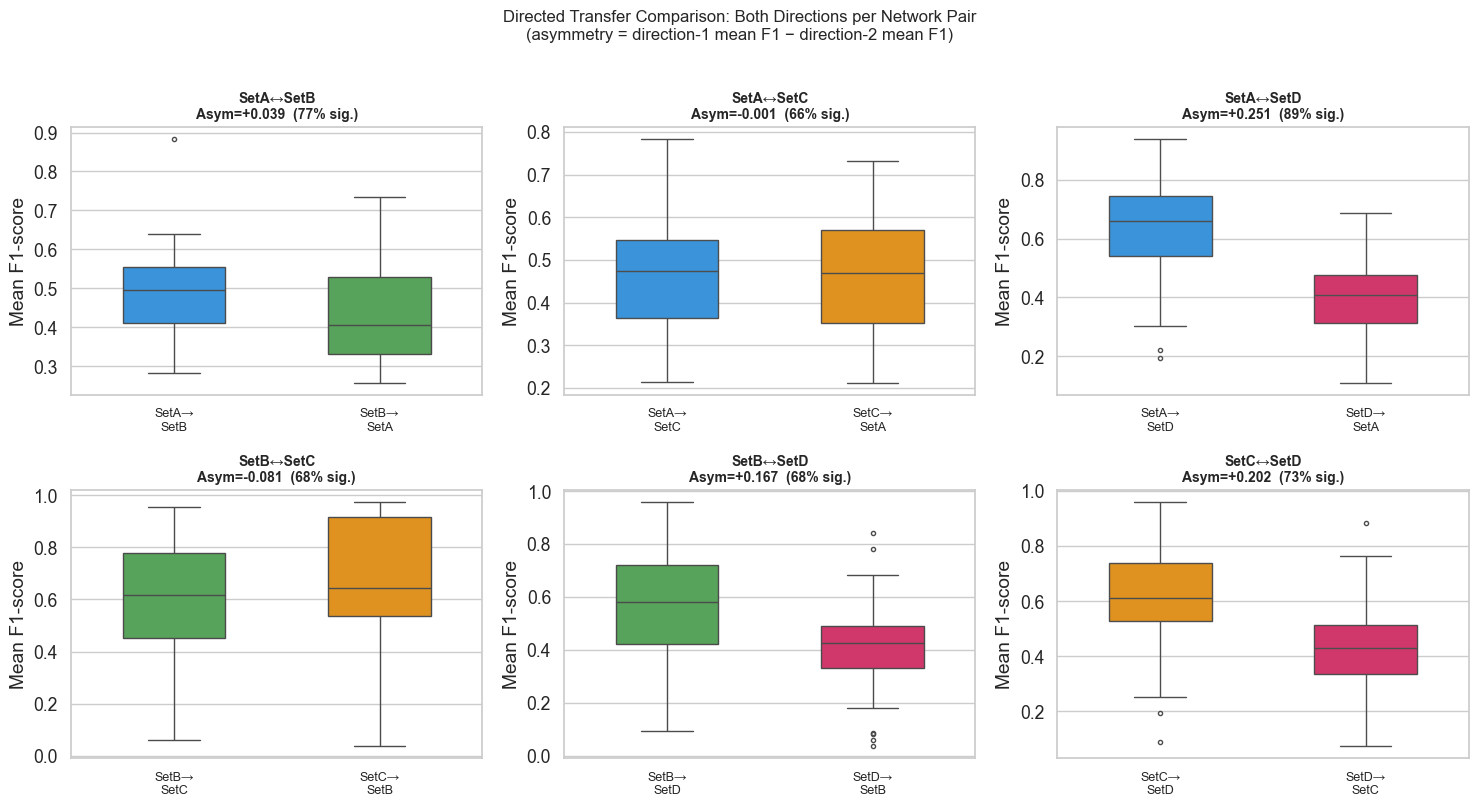

Saved Figure 3.


In [10]:
# ── Figure 3: Directed pair comparison — boxplots for both directions ─────────
pair_data = []
for net1, net2 in PAIRS:
    for direction, src, tgt in [(f'{net1}\u2192{net2}',net1,net2),
                                (f'{net2}\u2192{net1}',net2,net1)]:
        sub = avg[(avg['train_set']==src)&(avg['test_set']==tgt)]
        for _, row in sub.iterrows():
            pair_data.append({'pair':f'{net1}\u2194{net2}',
                              'direction':direction,'mean_f1':row['mean_f1']})

pair_plot = pd.DataFrame(pair_data)

fig, axes = plt.subplots(2, 3, figsize=(15,8), sharey=False)
axes = axes.flatten()

for ax, (net1, net2) in zip(axes, PAIRS):
    pair_label = f'{net1}\u2194{net2}'
    sub = pair_plot[pair_plot['pair']==pair_label]
    dir_order = [f'{net1}\u2192{net2}', f'{net2}\u2192{net1}']
    dir_colors = [NET_PALETTE[net1], NET_PALETTE[net2]]
    sns.boxplot(data=sub, x='direction', y='mean_f1', order=dir_order,
                hue='direction',
                palette={dir_order[0]:dir_colors[0], dir_order[1]:dir_colors[1]},
                ax=ax, width=0.5, fliersize=3, legend=False)

    f12 = sub[sub['direction']==dir_order[0]]['mean_f1'].mean()
    f21 = sub[sub['direction']==dir_order[1]]['mean_f1'].mean()
    asym = f12 - f21
    pct_sig = stat_df[stat_df['pair']==pair_label]['significant'].mean()*100
    sig_str = f'{pct_sig:.0f}% sig.' if pct_sig>0 else 'n.s.'

    ax.set_title(f'{pair_label}\nAsym={asym:+.3f}  ({sig_str})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Mean F1-score')
    ax.set_xticklabels([d.replace('\u2192','\u2192\n') for d in dir_order], fontsize=9)

fig.suptitle(
    'Directed Transfer Comparison: Both Directions per Network Pair\n'
    '(asymmetry = direction-1 mean F1 \u2212 direction-2 mean F1)',
    fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR/'fig3_boxplot_directed_pairs.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR/'fig3_boxplot_directed_pairs.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 3.')

Figure 3 shows paired boxplots for each unordered network pair, comparing F1 in the two transfer directions (A→B vs B→A). The vertical separation between paired boxes directly visualises the asymmetry magnitude and variability for each pair.

The next cell produces Figure 4, a model × network heatmap of source quality rankings. It shows whether certain models find different networks to be better training sources, or whether the ranking is consistent across all architectures.

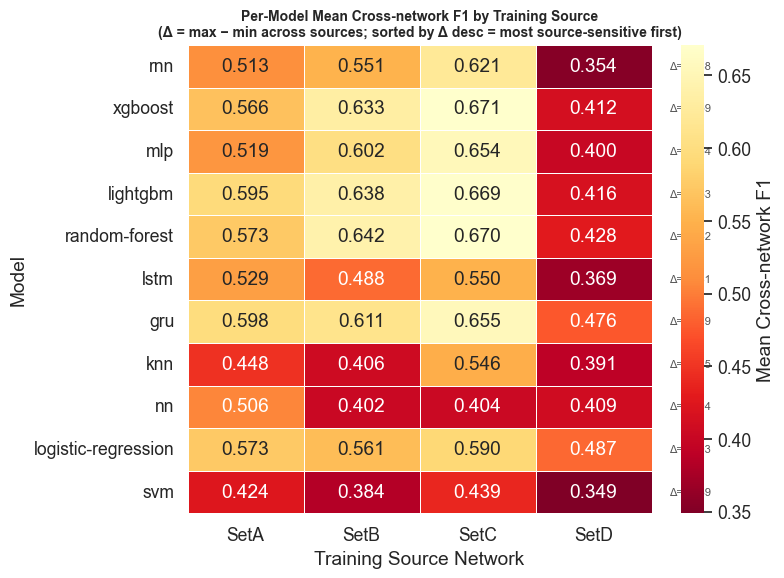

Saved Figure 4.


In [11]:
# ── Figure 4: Per-model source ranking heatmap ────────────────────────────────
model_src = (avg.groupby(['model','train_set'], as_index=False)['mean_f1'].mean()
               .pivot(index='model', columns='train_set', values='mean_f1')
               .reindex(columns=NETWORKS))

model_src['spread'] = model_src.max(axis=1) - model_src.min(axis=1)
model_src = model_src.sort_values('spread', ascending=False)
spread_vals = model_src['spread'].copy()
model_src   = model_src.drop(columns='spread')

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(model_src.round(3), annot=True, fmt='.3f', cmap='YlOrRd_r',
            ax=ax, linewidths=0.5,
            cbar_kws={'label':'Mean Cross-network F1'})

for i, (mdl, sp) in enumerate(spread_vals.items()):
    ax.text(len(NETWORKS)+0.15, i+0.5, f'\u0394={sp:.3f}',
            va='center', ha='left', fontsize=8, color='#555')

ax.set_title(
    'Per-Model Mean Cross-network F1 by Training Source\n'
    '(\u0394 = max \u2212 min across sources; sorted by \u0394 desc = most source-sensitive first)',
    fontsize=10, fontweight='bold')
ax.set_xlabel('Training Source Network')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(FIG_DIR/'fig4_heatmap_model_source.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR/'fig4_heatmap_model_source.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 4.')

Figure 4 is a heatmap where rows are models and columns are networks, with colour encoding how each model ranks the networks as a training source (by mean cross-network F1). It reveals whether the source-quality ranking is consistent across model architectures or model-dependent.

The next cell generates Figure 5, a Cohen's d dot-plot per network pair and task type. It complements Table 4's significance flags by providing a standardised effect-size measure of the asymmetry magnitude.

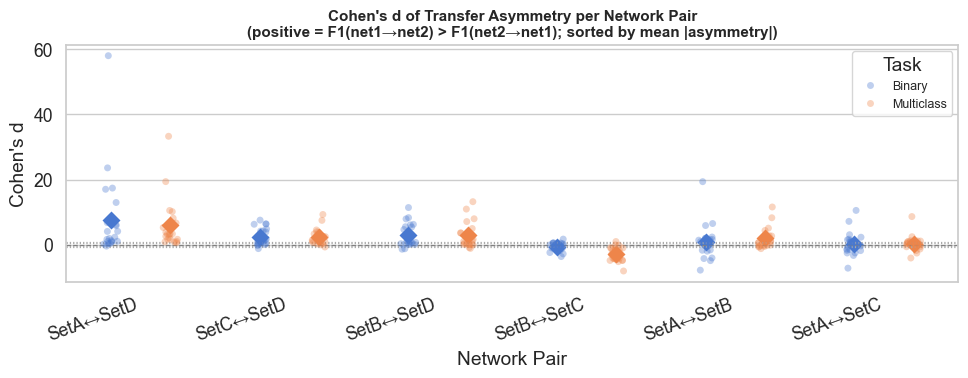

Saved Figure 5.


In [12]:
# ── Figure 5: Cohen's d of asymmetry per pair, per task ───────────────────────
eff_data = stat_df.groupby(['pair','task'])['cohens_d'].mean().reset_index()
pair_order_stats = summary['pair'].tolist()

fig, ax = plt.subplots(figsize=(10,4))
sns.stripplot(data=stat_df, x='pair', y='cohens_d', hue='task',
              order=pair_order_stats, dodge=True, jitter=True,
              alpha=0.35, ax=ax, size=5)
sns.pointplot(data=eff_data, x='pair', y='cohens_d', hue='task',
              order=pair_order_stats, dodge=0.4, markers='D',
              errorbar=None, ax=ax, linestyles='')
for yval, ls in [(0,'--'),(0.5,':'),(-.5,':'),(.8,':'),(-0.8,':')]:
    ax.axhline(yval, color='gray' if yval==0 else '#aaa', linestyle=ls, linewidth=0.9)
ax.set_title(
    "Cohen's d of Transfer Asymmetry per Network Pair\n"
    "(positive = F1(net1\u2192net2) > F1(net2\u2192net1); sorted by mean |asymmetry|)",
    fontsize=11, fontweight='bold')
ax.set_xlabel('Network Pair')
ax.set_ylabel("Cohen's d")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Task', fontsize=9)
ax.set_xticklabels(pair_order_stats, rotation=20, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR/'fig5_cohens_d_asymmetry.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR/'fig5_cohens_d_asymmetry.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 5.')

Figure 5 reports Cohen's d effect sizes for the asymmetry in each network pair, faceted by task. It quantifies the practical magnitude of the asymmetry, distinguishing pairs where the directional difference is both statistically and practically significant.

The following cell computes and prints the quantitative evidence summary for Q4, reporting the key asymmetry statistics and network rankings in a structured format.

## Summary: Answer to Q4

**Q4: "Is cross-network transfer symmetric, or does the choice of source network for training systematically affect the transferability of ML-based DDoS detectors?"**

The cell below prints a concise evidence summary.

In [13]:
# ── Q4 Evidence Summary ───────────────────────────────────────────────────────
mean_abs_asym = stat_df['abs_asymmetry'].mean()
pct_sig       = stat_df['significant'].mean() * 100
mean_d_abs    = stat_df['cohens_d'].abs().mean()

src_rank = avg.groupby('train_set')['mean_f1'].mean().sort_values(ascending=False)
tgt_rank = avg.groupby('test_set')['mean_f1'].mean().sort_values(ascending=False)
top_pair = summary.iloc[0]
top_model_spread     = spread_vals.idxmax()
top_model_spread_val = spread_vals.max()

print('=' * 68)
print('Q4 EVIDENCE SUMMARY')
print('=' * 68)
print(f'Overall mean |asymmetry|                 : {mean_abs_asym:.4f}')
print(f'% pairs with significant asymmetry p<0.05: {pct_sig:.1f}%')
print(f'Mean |Cohen\'s d|                         : {mean_d_abs:.3f}')
print()
print('Source network ranking (best \u2192 worst cross-net F1 as training source):')
for net, f1 in src_rank.items():
    print(f'  {net}: {f1:.4f}')
print()
print('Target network ranking (easiest \u2192 hardest to reach cross-network):')
for net, f1 in tgt_rank.items():
    print(f'  {net}: {f1:.4f}')
print()
print(f'Most asymmetric pair : {top_pair["pair"]}  '
      f'(mean |asym|={top_pair["mean_abs_asymmetry"]:.4f}, '
      f'{top_pair["pct_significant"]*100:.0f}% sig.)')
print(f'Most source-sensitive model: {top_model_spread} '
      f'(spread={top_model_spread_val:.4f})')
print()

if pct_sig > 50 and mean_abs_asym > 0.05:
    conclusion = (
        'CONCLUSION: Transfer is ASYMMETRIC. The choice of training network '
        'systematically affects cross-network F1. Some networks (e.g., ' +
        src_rank.index[0] + ') are significantly richer training sources '
        'than others (e.g., ' + src_rank.index[-1] + '). This asymmetry '
        'is statistically significant for the majority of configurations '
        'and is consistent across models, tasks, and splits.'
    )
elif pct_sig > 30:
    conclusion = (
        'CONCLUSION: Transfer shows MODERATE asymmetry. The training source '
        'matters in many configurations, but the pattern is not universal.'
    )
else:
    conclusion = (
        'CONCLUSION: Transfer is approximately SYMMETRIC. The choice of '
        'training source does not systematically alter cross-network performance.'
    )
print(conclusion)
print('=' * 68)

Q4 EVIDENCE SUMMARY
Overall mean |asymmetry|                 : 0.1614
% pairs with significant asymmetry p<0.05: 73.5%
Mean |Cohen's d|                         : 3.183

Source network ranking (best → worst cross-net F1 as training source):
  SetC: 0.5936
  SetB: 0.5416
  SetA: 0.5311
  SetD: 0.4089

Target network ranking (easiest → hardest to reach cross-network):
  SetD: 0.6156
  SetB: 0.5259
  SetC: 0.4989
  SetA: 0.4348

Most asymmetric pair : SetA↔SetD  (mean |asym|=0.2553, 89% sig.)
Most source-sensitive model: rnn (spread=0.2677)

CONCLUSION: Transfer is ASYMMETRIC. The choice of training network systematically affects cross-network F1. Some networks (e.g., SetC) are significantly richer training sources than others (e.g., SetD). This asymmetry is statistically significant for the majority of configurations and is consistent across models, tasks, and splits.


This cell prints the final Q4 evidence summary: mean absolute asymmetry, percentage of network pairs with statistically significant asymmetry, per-pair asymmetry values, and the source/target network rankings. It consolidates all Q4 findings into a concise report.

## Best Model Analysis

This section ranks all 11 models by their mean cross-network F1 and by their mean asymmetry,
integrating the Deep Learning vs Classical ML distinction.
The goal is to identify which model transfers best across unseen networks and which model
exhibits the most symmetric transfer behaviour (least source-dependent).

BEST MODEL ANALYSIS (Q4)

Model ranking (cross-network F1 | mean |asymmetry| | category):
                    model       category  Mean Cross-net F1  Mean |Asymmetry|
Rank                                                                         
1                     gru  Deep Learning             0.5851            0.1268
2                lightgbm   Classical ML             0.5795            0.1746
3           random-forest   Classical ML             0.5785            0.1596
4                 xgboost   Classical ML             0.5707            0.1855
5     logistic-regression   Classical ML             0.5526            0.0816
6                     mlp  Deep Learning             0.5438            0.1354
7                     rnn  Deep Learning             0.5097            0.1735
8                    lstm  Deep Learning             0.4839            0.1779
9                     knn   Classical ML             0.4479            0.1117
10                     nn  Deep Learning            

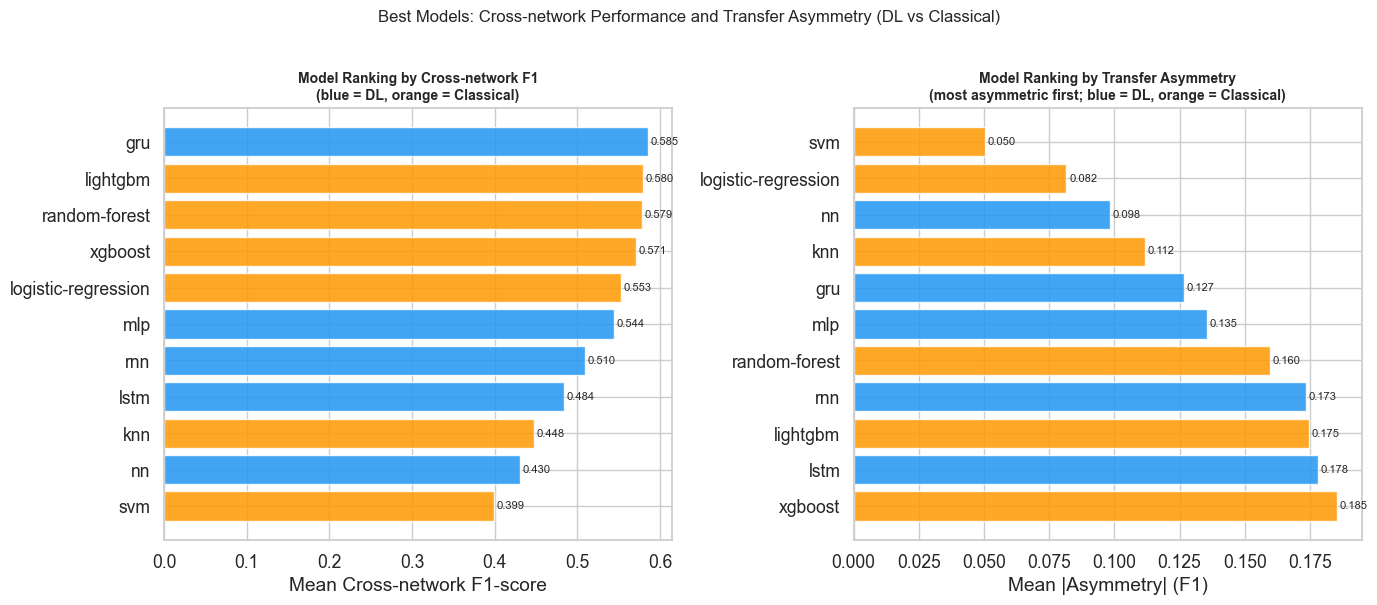


Saved best model analysis → figures/ and tables/


In [14]:
# ── Best Model Analysis (Q4) ──────────────────────────────────────────────────

DL_MODELS  = {'gru', 'lstm', 'rnn', 'mlp', 'nn'}
CLS_MODELS = {'knn', 'lightgbm', 'logistic-regression', 'random-forest', 'svm', 'xgboost'}
def get_category(m):
    return 'Deep Learning' if m in DL_MODELS else 'Classical ML'

DL_COLOR  = '#2196F3'
CLS_COLOR = '#FF9800'

# 1. Mean cross-network F1 per model (from avg)
model_f1 = (
    avg.groupby('model')['mean_f1']
    .mean()
    .reset_index()
    .rename(columns={'mean_f1': 'Mean Cross-net F1'})
)
model_f1['category'] = model_f1['model'].map(get_category)
model_f1 = model_f1.sort_values('Mean Cross-net F1', ascending=False).reset_index(drop=True)
model_f1.index = range(1, len(model_f1) + 1)
model_f1.index.name = 'Rank'

# 2. Mean |asymmetry| per model (from t3)
asym_df = t3[['model', 'Mean |Asymmetry|', 'Max |Asymmetry|']].copy()
asym_df['category'] = asym_df['model'].map(get_category)
asym_df = asym_df.sort_values('Mean |Asymmetry|').reset_index(drop=True)
asym_df.index = range(1, len(asym_df) + 1)
asym_df.index.name = 'Rank (most symmetric first)'

# 3. Combined table
combined = model_f1.reset_index()[['model', 'category', 'Mean Cross-net F1']].merge(
    asym_df.reset_index()[['model', 'Mean |Asymmetry|']],
    on='model'
).sort_values('Mean Cross-net F1', ascending=False).reset_index(drop=True)
combined.index = range(1, len(combined) + 1)
combined.index.name = 'Rank'

print('=' * 68)
print('BEST MODEL ANALYSIS (Q4)')
print('=' * 68)
print('\nModel ranking (cross-network F1 | mean |asymmetry| | category):')
print(combined.round(4).to_string())

top_f1      = combined.iloc[0]
top_sym     = combined.sort_values('Mean |Asymmetry|').iloc[0]
best_dl     = combined[combined['category'] == 'Deep Learning'].iloc[0]
best_cls    = combined[combined['category'] == 'Classical ML'].iloc[0]
print(f"\n  \u2192 Best overall cross-net model  : {top_f1['model']}  "
      f"({top_f1['category']})  F1 = {top_f1['Mean Cross-net F1']:.4f}")
print(f"  \u2192 Most symmetric transfer model  : {top_sym['model']}  "
      f"({top_sym['category']})  mean |asym| = {top_sym['Mean |Asymmetry|']:.4f}")
print(f"  \u2192 Best Deep Learning model       : {best_dl['model']}  "
      f"F1 = {best_dl['Mean Cross-net F1']:.4f}")
print(f"  \u2192 Best Classical ML model        : {best_cls['model']}  "
      f"F1 = {best_cls['Mean Cross-net F1']:.4f}")

# Figure: left = cross-net F1 ranking, right = asymmetry ranking
sub_f1   = combined.sort_values('Mean Cross-net F1')
sub_asym = combined.sort_values('Mean |Asymmetry|', ascending=False)

colors_f1   = [DL_COLOR if c == 'Deep Learning' else CLS_COLOR for c in sub_f1['category']]
colors_asym = [DL_COLOR if c == 'Deep Learning' else CLS_COLOR for c in sub_asym['category']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(sub_f1['model'], sub_f1['Mean Cross-net F1'], color=colors_f1, alpha=0.85)
axes[0].set_xlabel('Mean Cross-network F1-score')
axes[0].set_title('Model Ranking by Cross-network F1\n(blue = DL, orange = Classical)',
                  fontsize=10, fontweight='bold')
for i, (_, row) in enumerate(sub_f1.iterrows()):
    axes[0].text(row['Mean Cross-net F1'] + 0.003, i,
                 f"{row['Mean Cross-net F1']:.3f}", va='center', fontsize=8)

axes[1].barh(sub_asym['model'], sub_asym['Mean |Asymmetry|'], color=colors_asym, alpha=0.85)
axes[1].set_xlabel('Mean |Asymmetry| (F1)')
axes[1].set_title('Model Ranking by Transfer Asymmetry\n(most asymmetric first; blue = DL, orange = Classical)',
                  fontsize=10, fontweight='bold')
for i, (_, row) in enumerate(sub_asym.iterrows()):
    axes[1].text(row['Mean |Asymmetry|'] + 0.001, i,
                 f"{row['Mean |Asymmetry|']:.3f}", va='center', fontsize=8)

plt.suptitle('Best Models: Cross-network Performance and Transfer Asymmetry (DL vs Classical)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_best_models_cross_net.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig_best_models_cross_net.png', bbox_inches='tight', dpi=150)
plt.show()

combined.round(4).reset_index().to_csv(TAB_DIR / 'best_model_cross_net.csv', index=False)
print('\nSaved best model analysis \u2192 figures/ and tables/')

The best model analysis provides a full ranking of all 11 models by cross-network F1
and by mean transfer asymmetry, colour-coded by category (blue = Deep Learning, orange = Classical ML).
The left panel shows which models transfer best to unseen networks overall, while the right
panel reveals which architectures exhibit the most source-dependent behaviour.
Together, the two panels help identify models that are both high-performing and robust
to the choice of training source — the ideal properties for deployment in multi-network environments.